In [3]:
import pandas as pd
import numpy as np
import os
import sys
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.stats import zscore

from tqdm import tqdm

import xml.etree.ElementTree as ET
from tifffile import imread
from tifffile import TiffFile

from skimage import io
from skimage.color import rgb2gray
from skimage.color import label2rgb
from skimage.transform import rescale
from skimage.exposure import rescale_intensity, equalize_adapthist
from skimage.measure import regionprops
from skimage.measure import regionprops_table
from skimage.segmentation import mark_boundaries
from skimage.filters import gaussian, median

from skimage.morphology import white_tophat, disk

# stardist
from csbdeep.utils import normalize
from stardist.models import StarDist2D

import logging
logging.getLogger("tifffile").setLevel(logging.ERROR)

bioimageio_utils.py (2): pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
2026-03-18 13:26:11.223106: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [30]:
import tifffile

with tifffile.TiffFile('/scratch/indikar_root/indikar1/jrcwycy/HYB/HYB04/day8_test/day8-B2_s1.ome.tiff') as tif:
    print(f"Number of series: {len(tif.series)}")
    for i, series in enumerate(tif.series):
        print(f"\nSeries {i}: shape={series.shape}, dtype={series.dtype}, name={series.name}")
    
    # Check pixel data range to see if it looks raw or 8-bit display
    data = tif.asarray()
    print(f"\nData dtype: {data.dtype}")
    print(f"Min: {data.min()}, Max: {data.max()}")
    
    # print(tif.ome_metadata)

Number of series: 1

Series 0: shape=(3, 288, 350, 3), dtype=uint8, name=

Data dtype: uint8
Min: 0, Max: 254


# Load images

OME.TIFF files were exported from the CD7 (Zen Blue) with Display Settings and Channel Color applied (used the same settings for each image). 
Raw files are (C, Y, X, RGB). Images are converted to grayscale for background subtraction.

In [4]:
def extract_grayscale(img):
    """
    Extract grayscale from (C, Y, X, 3) using the appropriate method per channel.
    rgb2gray uses ITU-R 601-2 luma transform: 0.2126R + 0.7152G + 0.0722B
    Output is scaled back to original dtype range.
    """
    gray_channels = []
    vmax = np.iinfo(img.dtype).max

    for c in range(img.shape[0]):
        plane = img[c]  # (Y, X, 3)
        gray  = rgb2gray(plane)           # float64 in [0, 1]
        gray  = (gray * vmax).astype(img.dtype)
        gray_channels.append(gray)

        # print(f"Ch {c} ({info['channels'][c]}): "
        #       f"min={gray.min()}, max={gray.max()}, "
        #       f"mean={gray.mean():.2f}, nonzero={np.count_nonzero(gray)}")

    return np.stack(gray_channels, axis=0)  # (C, Y, X)

dpi = 75

In [6]:
# img_dir = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HYB04/images_day8/"
img_dir = "/scratch/indikar_root/indikar1/jrcwycy/HYB/HYB04/day8_test/"

raw_imgs = {}
imgs = {}

# counter = 0

for f in os.listdir(img_dir):
    # label = f.split('well')[1].split('_')[0]
    label = f.split('day8-')[1].split('_')[0]
    fullpath = f"{img_dir}{f}"
    
    img = imread(fullpath)
    raw_imgs[label] = img
    
    img_gray = extract_grayscale(img)
    imgs[label] = img_gray
    
    print(f"{label} {img_gray.shape=}")
    
#     counter += 1
#     if counter > 3:
#         break
    
print('\nDone!\n')

print(f"N images: {len(imgs.keys())}")
print(sorted(imgs.keys()))

B6 img_gray.shape=(3, 288, 350)
F4 img_gray.shape=(3, 288, 350)
F5 img_gray.shape=(3, 288, 350)
E6 img_gray.shape=(3, 288, 350)
D4 img_gray.shape=(3, 288, 350)
D5 img_gray.shape=(3, 288, 350)
C3 img_gray.shape=(3, 288, 350)
C2-v2 img_gray.shape=(3, 288, 350)
B3 img_gray.shape=(3, 288, 350)
D2-v2 img_gray.shape=(3, 288, 350)
D3 img_gray.shape=(3, 288, 350)
C5 img_gray.shape=(3, 288, 350)
C6 img_gray.shape=(3, 288, 350)
F6 img_gray.shape=(3, 288, 350)
C2 img_gray.shape=(3, 288, 350)
B5 img_gray.shape=(3, 288, 351)
B2 img_gray.shape=(3, 288, 350)
G5 img_gray.shape=(3, 288, 350)
D6 img_gray.shape=(3, 288, 350)
D2 img_gray.shape=(3, 288, 350)

Done!

N images: 20
['B2', 'B3', 'B5', 'B6', 'C2', 'C2-v2', 'C3', 'C5', 'C6', 'D2', 'D2-v2', 'D3', 'D4', 'D5', 'D6', 'E6', 'F4', 'F5', 'F6', 'G5']


## Check color

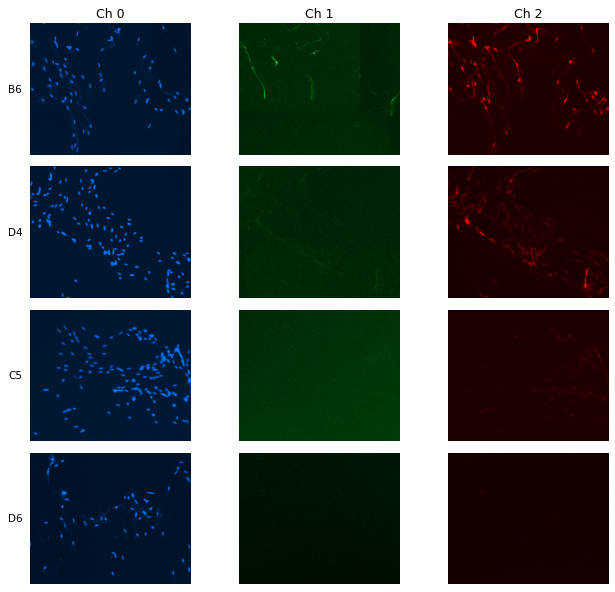

In [7]:
test_imgs = ['B6', 'D4', 'C5', 'D6']

# labels = list(imgs.keys())
n_rows = len(test_imgs)
n_channels = 3


fig, axes = plt.subplots(n_rows, n_channels, figsize=(3*n_channels, 2*n_rows), dpi=dpi)

for r, label in enumerate(test_imgs):
    img = raw_imgs[label]   # shape (C,Y,X)

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        ax.imshow(img[c])
        ax.axis('off')

        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)

plt.tight_layout()
plt.show()

## Check grayscale

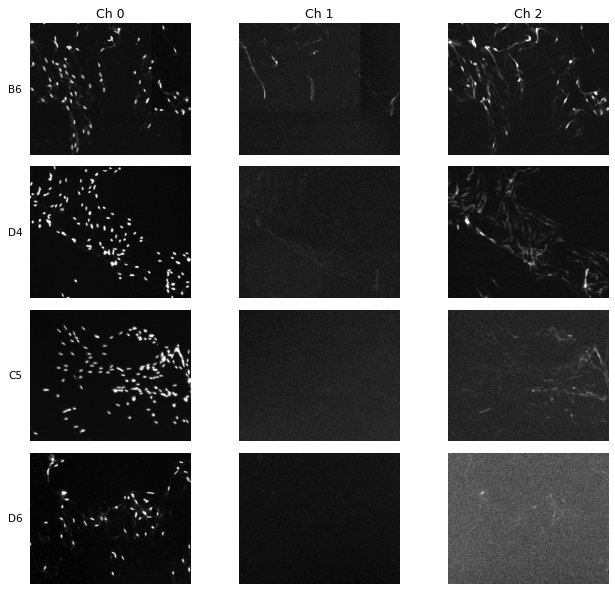

In [8]:
fig, axes = plt.subplots(n_rows, n_channels, figsize=(3*n_channels, 2*n_rows), dpi=dpi)

for r, label in enumerate(test_imgs):
    img = imgs[label]   # shape (C,Y,X)

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        ax.imshow(img[c], cmap='gray')
        ax.axis('off')

        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)

plt.tight_layout()
plt.show()

# Helper functions

In [9]:
def subtract_background_by_channel(img, ref_background, radius=10,
                                    per_image_channels=(0,),
                                    reference_channels=(1, 2)):
    """
    Apply different background subtraction strategies per channel.

    Parameters
    ----------
    img                 : ndarray, shape (C, Y, X) — image to correct
    ref_background      : ndarray, shape (C, Y, X) — reference background
    radius              : int, rolling ball radius for per-image channels (Hoechst)
    per_image_channels  : tuple, channel indices to use per-image subtraction
    reference_channels  : tuple, channel indices to use reference subtraction

    Returns
    -------
    corrected : ndarray, same shape/dtype as img
    """
    selem     = disk(radius)
    corrected = np.zeros_like(img)

    for c in range(img.shape[0]):
        plane = img[c]

        if c in per_image_channels:
            # Rolling ball per-image (Hoechst)
            bg   = plane - white_tophat(plane, selem)
            corr = np.clip(
                       plane.astype(np.int32) - bg.astype(np.int32),
                       0, None
                   )

        elif c in reference_channels:
            # Reference background subtraction (MyoD, MYH4)
            bg   = ref_background[c]
            corr = np.clip(
                       plane.astype(np.int32) - bg.astype(np.int32),
                       0, None
                   )
        else:
            corr = plane

        corrected[c] = corr.astype(img.dtype)

    return corrected


def build_composite(corrected_gray, channel_colors, norm_max=None, per_image_channels=(0,)):
    """
    Build a composite image (overlaid channels). Normalization is applied per-image for the Hoechst channel.
    A global reference max from positive controls are used for normalizing AF488 and AF594.
    
    """
    
    composite = np.zeros((*corrected_gray.shape[1:], 3), dtype=np.float32)

    for c, color in enumerate(channel_colors):
        plane = corrected_gray[c].astype(np.float32)

        # Hoechst (or any per_image_channels) → always per-image normalization
        if c in per_image_channels:
            cmax = plane.max() if plane.max() > 0 else 1.0
        # All other channels → global reference max if provided
        elif norm_max is not None:
            cmax = norm_max[c] if norm_max[c] > 0 else 1.0
        else:
            cmax = plane.max() if plane.max() > 0 else 1.0

        if cmax == 0:
            print(f"Warning: Channel {c} is blank — skipping.")
            continue

        plane_norm = np.clip(plane / cmax, 0, 1)
        composite += plane_norm[..., np.newaxis] * color

    return np.clip(composite, 0, 1)



def add_scale_bar(ax, pixel_size_um, image_width_px, 
                  bar_um=50, color="white", fontsize=8):
    """
    Add a scale bar to a matplotlib axis.

    Parameters
    ----------
    ax             : matplotlib axis
    pixel_size_um  : float, physical size of one pixel in µm
    image_width_px : int, width of the image in pixels (for positioning)
    bar_um         : float, desired scale bar length in µm
    color          : str, color of the scale bar and label
    fontsize       : int, font size of the label
    """
    bar_px = bar_um / pixel_size_um  # convert µm → pixels

    # Position: bottom-right corner with a small margin
    margin_x = image_width_px * 0.04
    margin_y = image_width_px * 0.04
    x_end    = image_width_px - margin_x
    x_start  = x_end - bar_px
    y_pos    = img.shape[1] - margin_y  # near bottom

    ax.plot([x_start, x_end], [y_pos, y_pos],
            color=color, linewidth=1.5, solid_capstyle="butt")

## Define reference background

In [10]:
print(sorted(imgs.keys()))

['B2', 'B3', 'B5', 'B6', 'C2', 'C2-v2', 'C3', 'C5', 'C6', 'D2', 'D2-v2', 'D3', 'D4', 'D5', 'D6', 'E6', 'F4', 'F5', 'F6', 'G5']


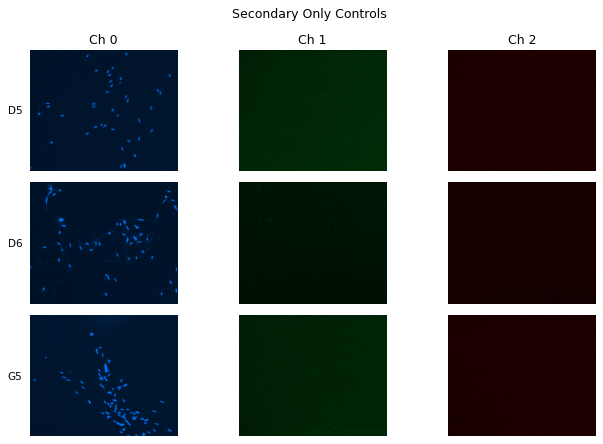

In [12]:
# secondary onlys --> D5, D6
test_imgs = ['D5', 'D6', 'G5']
n_rows = len(test_imgs)
n_channels = 3

fig, axes = plt.subplots(n_rows, n_channels, figsize=(3*n_channels, 2*n_rows), dpi=dpi)

for r, label in enumerate(test_imgs):
    img = raw_imgs[label]   # shape (C,Y,X)

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        ax.imshow(img[c])
        ax.axis('off')

        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)


plt.suptitle("Secondary Only Controls")            
plt.tight_layout()
plt.show()

(3, 3, 288, 350)
(3, 288, 350)
Reference background per channel:
  Ch 0: min=14, max=74, mean=18.30
  Ch 1: min=12, max=76, mean=21.09
  Ch 2: min=3, max=7, mean=4.79


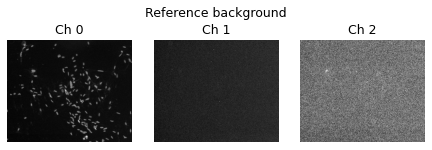

In [13]:
# extract secondary only controls (grayscale)
sec_keys = ['D5', 'D6', 'G5']

sec_only = np.stack([imgs[k] for k in sec_keys], axis=0) # 3, C, Y, X
print(sec_only.shape)

# average to get reference background
ref_background = sec_only.mean(axis=0).astype(sec_only.dtype)
print(ref_background.shape)

print("Reference background per channel:")
for c in range(ref_background.shape[0]):
    print(f"  Ch {c}: "
          f"min={ref_background[c].min()}, "
          f"max={ref_background[c].max()}, "
          f"mean={ref_background[c].mean():.2f}")
    

# plot    
fig, axes = plt.subplots(1, 3, figsize=(6, 2), dpi=dpi)

for c in range(3):
    ax = axes[c]
    ax.imshow(ref_background[c], cmap='gray')
    ax.axis('off')
    ax.set_title(f'Ch {c}')

plt.suptitle("Reference background")
plt.tight_layout()
plt.show()

# Background subtraction

B5 shape after crop: (3, 288, 350)

Secondary only 1:
  Ch 1: mean=0.01, max=97
  Ch 2: mean=0.09, max=4

Cells only:
  Ch 1: mean=15.67, max=153
  Ch 2: mean=1.38, max=24

IMR90:
  Ch 1: mean=1.48, max=166
  Ch 2: mean=0.94, max=49

mmRNA #3:
  Ch 1: mean=6.15, max=148
  Ch 2: mean=1.54, max=50


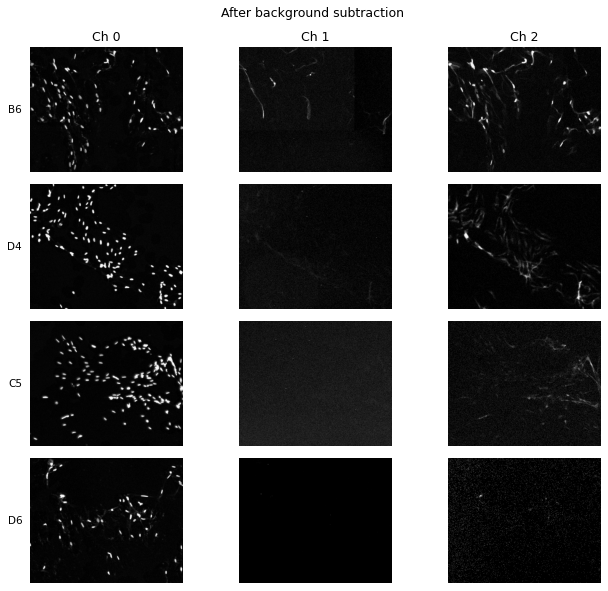

In [15]:
### -------- Background subtraction --------

corrected_imgs = {}
radius = 10

# well B5 has diff shape (3, 288, 351); rest are (3, 288, 350)
imgs['B5'] = imgs['B5'][:, :, :350]
print(f"B5 shape after crop: {imgs['B5'].shape}")

for i, (label, image) in enumerate(imgs.items()):
    # per-image for Hoechst; otherwise subtracts reference background
    corr = subtract_background_by_channel(image, ref_background, radius=radius) 
    corrected_imgs[label] = corr
  


## After correction, check that:
# 1. Secondary-only wells → near zero signal in Ch1 and Ch2
# 2. Cells-only → near zero signal in Ch1 and Ch2
# 3. IMR90 → strong positive signal in Ch1 and/or Ch2

for name, img_corr in [("Secondary only 1", corrected_imgs['D6']),
                        ("Cells only",       corrected_imgs['C5']),
                        ("IMR90",            corrected_imgs['C6']),
                        ("mmRNA #3",         corrected_imgs['D4'])]:
    print(f"\n{name}:")
    for c in [1, 2]:  # MYH4 and MyoD only
        print(f"  Ch {c}: "
              f"mean={img_corr[c].mean():.2f}, "
              f"max={img_corr[c].max()}")
        

# plot     
test_imgs = ['B6', 'D4', 'C5', 'D6']
n_rows = len(test_imgs)
n_channels = 3

fig, axes = plt.subplots(n_rows, n_channels, figsize=(3*n_channels, 2*n_rows), dpi=dpi)

for r, label in enumerate(test_imgs):
    img = corrected_imgs[label]   # shape (C,Y,X)

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        ax.imshow(img[c], cmap='gray')
        ax.axis('off')

        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)


plt.suptitle("After background subtraction")            
plt.tight_layout()
plt.show()

# Build composites

## Check positive controls

In [16]:
print(sorted(imgs.keys()))

['B2', 'B3', 'B5', 'B6', 'C2', 'C2-v2', 'C3', 'C5', 'C6', 'D2', 'D2-v2', 'D3', 'D4', 'D5', 'D6', 'E6', 'F4', 'F5', 'F6', 'G5']


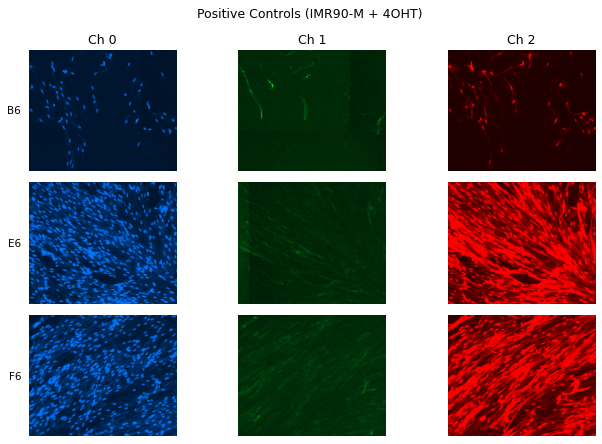

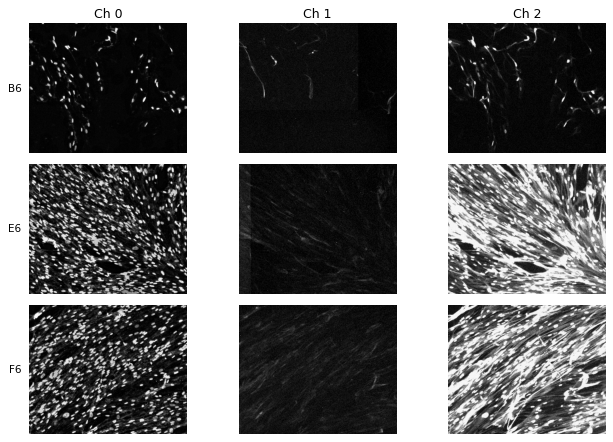

In [23]:
test_imgs = ['B6', 'E6', 'F6']
n_rows = len(test_imgs)
n_channels = 3

fig, axes = plt.subplots(n_rows, n_channels, figsize=(3*n_channels, 2*n_rows), dpi=dpi)

for r, label in enumerate(test_imgs):
    img = raw_imgs[label]   # shape (C,Y,X)

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        ax.imshow(img[c])
        ax.axis('off')

        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)


plt.suptitle("Positive Controls (IMR90-M + 4OHT)")            
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(n_rows, n_channels, figsize=(3*n_channels, 2*n_rows), dpi=dpi)

for r, label in enumerate(test_imgs):
    img = corrected_imgs[label]   # shape (C,Y,X)

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        ax.imshow(img[c], cmap='gray')
        ax.axis('off')

        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)
         
plt.tight_layout()
plt.show()

In [24]:
# compute reference max signal from pos control
# ref_wells = ['B6', 'C6']
# ref_wells = ['B6']
ref_wells = ['B6', 'E6', 'F6']

ref_stack = np.stack([corrected_imgs[r] for r in ref_wells], axis=0) # N, C, Y, X
ref_max = {c: ref_stack[:, c].max() for c in range(3)}

print("Reference max signal per channel:")
for c in range(3):
    print(f"Ch {c}: {ref_max[c]}")
    

# percentile-based 
# p = 99.5

# ref_signal = {
#     c: np.percentile(
#         np.concatenate([corrected_imgs[r][c].ravel() for r in ref_wells]),
#         p
#     )
#     for c in range(3)
# }

# print(f"Reference {p}th percentile signal per channel:")
# for c in range(3):
#     print(f"Ch {c}: {ref_signal[c]:.2f}")


# Percentile-based for positive pixels
p = 99.5
n_channels = corrected_imgs[ref_wells[0]].shape[0]

ref_signal = {}

for c in range(n_channels):

    signal_pixels = []

    for w in ref_wells:
        img = corrected_imgs[w][c].astype(np.float32)
        signal_pixels.append(img[img > 0])   # keep positive pixels only

    signal_pixels = np.concatenate(signal_pixels)

    if signal_pixels.size > 0:
        ref_signal[c] = np.percentile(signal_pixels, p)
    else:
        ref_signal[c] = 1.0

print("\nReference signal per channel:")
for c in range(n_channels):
    print(f"Ch {c}: {ref_signal[c]:.2f}")

Reference max signal per channel:
Ch 0: 87
Ch 1: 168
Ch 2: 50

Reference signal per channel:
Ch 0: 80.00
Ch 1: 37.00
Ch 2: 49.00


In [25]:
# -------- Build composite images --------

# define channel colors
lut_colors = {
    "red":     np.array([1, 0, 0]),
    "green":   np.array([0, 1, 0]),
    "blue":    np.array([0, 0, 1]),
    "cyan":    np.array([0, 1, 1]),
    "magenta": np.array([1, 0, 1]),
    "yellow":  np.array([1, 1, 0]),
    "gray":    np.array([1, 1, 1]),
}

channel_colors = [
    lut_colors["blue"],    # Ch0 — Hoechst
    lut_colors["green"],   # Ch1 — AF488
    lut_colors["red"],     # Ch2 — AF594
]


print("Building composites...")   
composites = {
    label: build_composite(corr, channel_colors, norm_max=ref_signal, per_image_channels=(0,))
    for label, corr in corrected_imgs.items()
}

print("Done!")

Building composites...
Done!


# Plot

In [21]:
print(sorted(imgs.keys()))

['B2', 'B3', 'B5', 'B6', 'C2', 'C2-v2', 'C3', 'C5', 'C6', 'D2', 'D2-v2', 'D3', 'D4', 'D5', 'D6', 'E6', 'F4', 'F5', 'F6', 'G5']


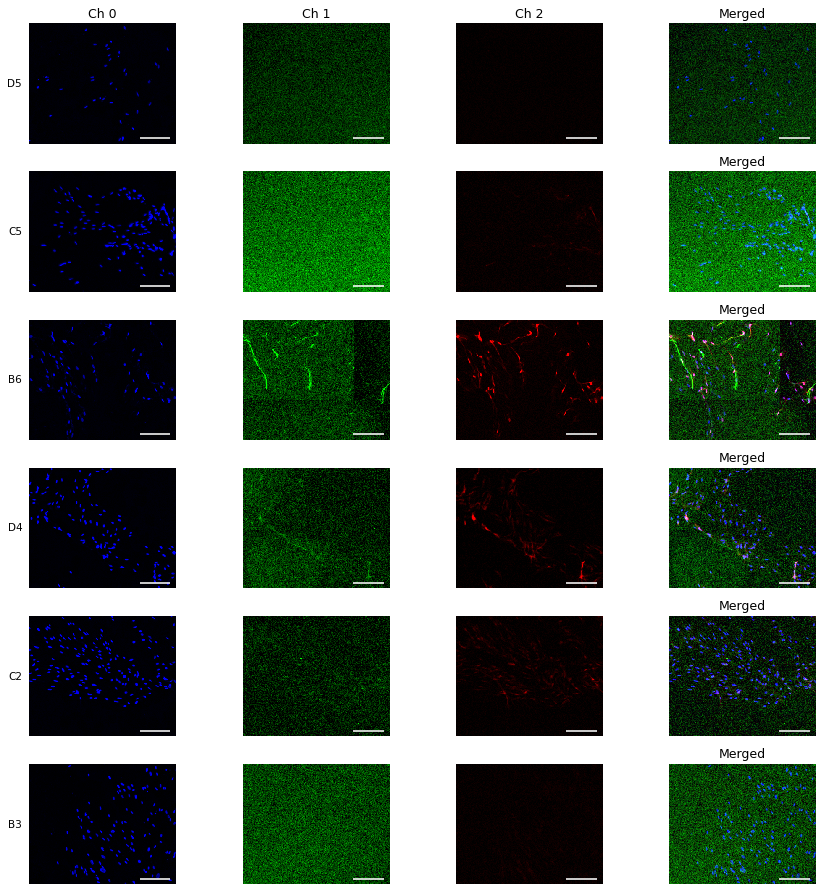

In [26]:
pixel_size_um  = 2.724 # pixel size in microns
scale_bar_length = 200 # microns

test_imgs = [
    'D5', # Secondary only control
    'C5', # BJ only control (neg)
    'B6', # IMR90-M control (pos)
    'D4', # Wacker
    'C2', # Trilink #1
    'B3', # Trilink #2
]
    

n_rows = len(test_imgs)
n_cols = 4 # each channel + composite

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows), dpi=dpi)

for r, label in enumerate(test_imgs):
    
    img = corrected_imgs[label]   # shape (C,Y,X)
    composite = composites[label]
    image_width_px = composite.shape[1]

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        
        plane = img[c].astype(np.float32)
        
        # Normalize 
        if c == 0: # Hoechst
            cmax = plane.max() if plane.max() > 0 else 1.0 # keep at max to maximize contrast of nuclei (not comparing across wells) 
        else:
            # cmax = ref_max[c] if ref_max[c] > 0 else 1.0 # to global reference max 
            cmax = ref_signal[c] if ref_signal[c] > 0 else 1.0 # to percentile-based reference
        
        
        plane_norm = np.clip(plane / cmax, 0, 1)
        colorized = plane_norm[..., np.newaxis] * channel_colors[c]
        
        ax.imshow(colorized, interpolation='nearest')
        ax.axis('off')     
        
        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)
            
        add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)
        
    # composite
    ax = axes[r, 3] if n_rows > 1 else axes[3]

    ax.imshow(composite, interpolation='nearest')
    ax.axis('off')
    ax.set_title("Merged")
    add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)

plt.tight_layout()
plt.show()

In [7]:
print(sorted(imgs.keys()))

['B2', 'B3', 'B5', 'B6', 'C2', 'C4', 'C5', 'C6', 'D2', 'D3', 'D4', 'D5', 'D6']


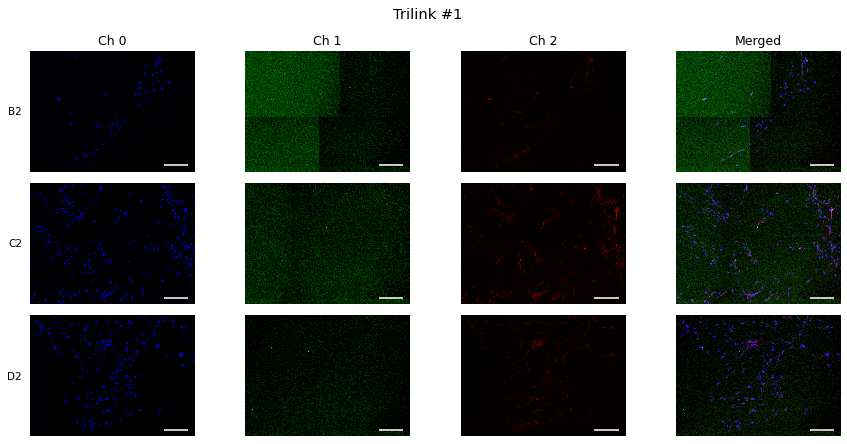

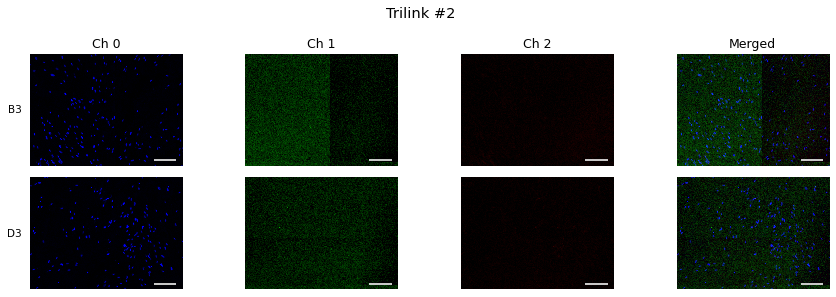

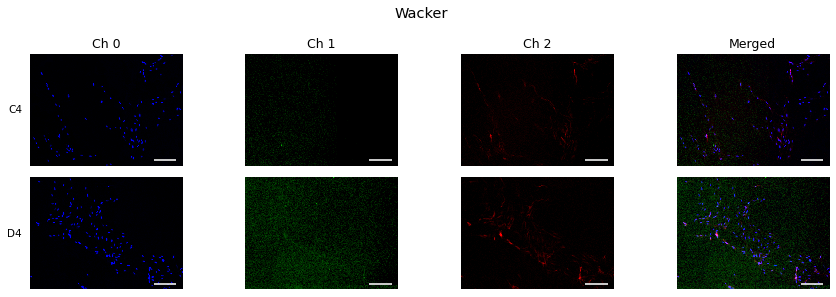

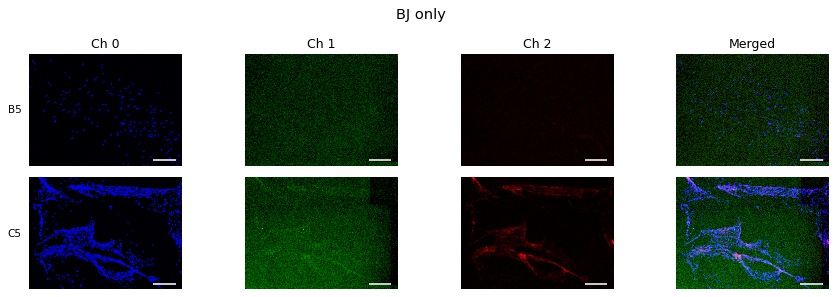

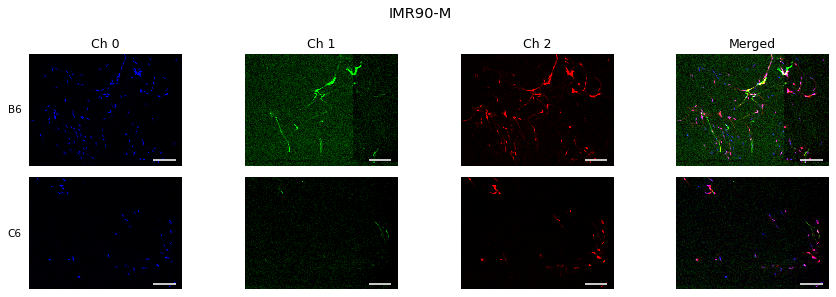

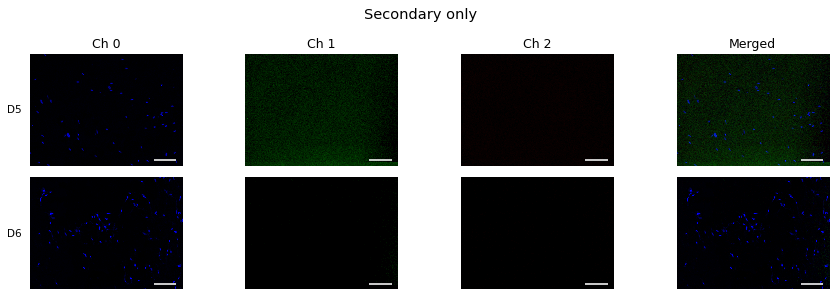

In [18]:
## Day 5
label_map = {
    'Trilink #1': ['B2', 'C2', 'D2'],
    'Trilink #2': ['B3', 'D3'],
    'Wacker': ['C4', 'D4'],
    
    'BJ only': ['B5', 'C5'],
    'IMR90-M': ['B6', 'C6'],
    
    # # Controls
    # 'Trilink #1 (No 4OHT)': ['E2', 'F2'],
    # 'Trilink #2 (No 4OHT)': ['E3', 'F3'],
    # 'Wacker (No 4OHT)': ['E4', 'F4'],
    # 'BJ only (No 4OHT)': ['E5', 'F5'],
    # 'IMR90-M (No 4OHT)': ['E6', 'F6'],
    
    'Secondary only': ['D5', 'D6'],
}

pixel_size_um  = 2.724
scale_bar_length = 200

for group_label, wells in label_map.items():

    n_rows = len(wells)
    n_cols = 4

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows), dpi=dpi)

    if n_rows == 1:
        axes = axes[np.newaxis, :]  # ensure 2D indexing

    for r, well in enumerate(wells):

        img = corrected_imgs[well]
        composite = composites[well]
        image_width_px = composite.shape[1]

        for c in range(n_channels):

            ax = axes[r, c]

            plane = img[c].astype(np.float32)

            # normalization
            if c == 0:  # Hoechst
                cmax = plane.max() if plane.max() > 0 else 1.0
            else:
                cmax = ref_signal[c] if ref_signal[c] > 0 else 1.0

            plane_norm = np.clip(plane / cmax, 0, 1)
            colorized = plane_norm[..., np.newaxis] * channel_colors[c]

            ax.imshow(colorized, interpolation='nearest')
            ax.axis('off')

            if r == 0:
                ax.set_title(f'Ch {c}')

            if c == 0:
                ax.text(-0.05, 0.5, well, transform=ax.transAxes, va='center', ha='right', fontsize=10)

            add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)

        # composite
        ax = axes[r, 3]
        ax.imshow(composite, interpolation='nearest')
        ax.axis('off')

        if r == 0:
            ax.set_title("Merged")

        add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)

    fig.suptitle(group_label, fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
break

#

# OLD

In [ ]:
### OLD

def subtract_rolling_ball_2d(img, radius=10):
    """
    Rolling ball background subtraction for shape (C, Y, X).

    Parameters
    ----------
    img    : ndarray, shape (C, Y, X)
    radius : int, rolling ball radius in pixels

    Returns
    -------
    corrected   : ndarray, same shape/dtype as img
    backgrounds : ndarray, same shape as img
    """
    assert img.ndim == 3, f"Expected (C, Y, X), got {img.shape}"
    selem = disk(radius)
    corrected   = np.zeros_like(img)
    backgrounds = np.zeros_like(img)

    for c in tqdm(range(img.shape[0]), desc="Channels"):
        plane = img[c]
        bg    = plane - white_tophat(plane, selem)
        corr  = np.clip(
                    plane.astype(np.int32) - bg.astype(np.int32),
                    0, None
                )
        corrected[c]   = corr.astype(img.dtype)
        backgrounds[c] = bg.astype(img.dtype)

    return corrected, backgrounds



def build_composite(corrected_gray, channel_colors):
    """
    Build a true composite image from grayscale channels and LUT colors.

    Parameters
    ----------
    corrected_gray  : ndarray, shape (C, Y, X)
    channel_colors  : list of arrays, each shape (3,) — RGB color per channel

    Returns
    -------
    composite : ndarray, shape (Y, X, 3), float32 in [0, 1]
    """
    composite = np.zeros((*corrected_gray.shape[1:], 3), dtype=np.float32)

    for c, color in enumerate(channel_colors):
        plane      = corrected_gray[c].astype(np.float32)
        plane_norm = plane / plane.max()                        # normalize to [0, 1]
        composite += plane_norm[..., np.newaxis] * color        # colorize and add

    return np.clip(composite, 0, 1)

# Customize these to match your stains
lut_colors = {
    "red":     np.array([1, 0, 0]),
    "green":   np.array([0, 1, 0]),
    "blue":    np.array([0, 0, 1]),
    "cyan":    np.array([0, 1, 1]),
    "magenta": np.array([1, 0, 1]),
    "yellow":  np.array([1, 1, 0]),
    "gray":    np.array([1, 1, 1]),
}

# Assign a color to each channel — adjust to your stains
channel_colors = [
    lut_colors["blue"],    # Ch0 — e.g. DAPI
    lut_colors["green"],   # Ch1 — e.g. GFP
    lut_colors["red"],     # Ch2 — e.g. mCherry
]

## per-image background subtraction

In [ ]:
corrected_imgs = {}
backgrounds = {}
composites = {}

radius_px = 10


for i, (label, image) in enumerate(imgs.items()):
    # background subtraction
    corr, bkg = subtract_rolling_ball_2d(image, radius=radius_px)
    
    corrected_imgs[label] = corr
    backgrounds[label] = bkg

    # create composite image (w/ color)
    comp = build_composite(corr, channel_colors)
    composites[label] = comp

In [ ]:
test_imgs = ['B6', 'D4', 'C5']
n_rows = len(test_imgs)
n_channels = 3

fig, axes = plt.subplots(n_rows, n_channels, figsize=(3*n_channels, 2*n_rows))

for r, label in enumerate(test_imgs):
    img = corrected_imgs[label]   # shape (C,Y,X)

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        ax.imshow(img[c], cmap='gray')
        ax.axis('off')
        
        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
def add_scale_bar(ax, pixel_size_um, image_width_px, 
                  bar_um=50, color="white", fontsize=8):
    """
    Add a scale bar to a matplotlib axis.

    Parameters
    ----------
    ax             : matplotlib axis
    pixel_size_um  : float, physical size of one pixel in µm
    image_width_px : int, width of the image in pixels (for positioning)
    bar_um         : float, desired scale bar length in µm
    color          : str, color of the scale bar and label
    fontsize       : int, font size of the label
    """
    bar_px = bar_um / pixel_size_um  # convert µm → pixels

    # Position: bottom-right corner with a small margin
    margin_x = image_width_px * 0.04
    margin_y = image_width_px * 0.04
    x_end    = image_width_px - margin_x
    x_start  = x_end - bar_px
    y_pos    = img.shape[1] - margin_y  # near bottom

    ax.plot([x_start, x_end], [y_pos, y_pos],
            color=color, linewidth=1.5, solid_capstyle="butt")

In [ ]:
pixel_size_um  = 2.724 # pixel size in microns
# image_width_px = composite.shape[1]
scale_bar_length = 200 # microns

n_rows = len(test_imgs)
n_cols = 4 # each channel + composite

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))

for r, label in enumerate(test_imgs):
    
    img = corrected_imgs[label]   # shape (C,Y,X)
    composite = composites[label]
    image_width_px = composite.shape[1]

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        
        plane_norm = img[c].astype(np.float32) / img[c].max()
        colorized = np.clip(plane_norm[..., np.newaxis] * channel_colors[c], 0, 1)
        
        ax.imshow(colorized, interpolation='nearest')
        ax.axis('off')     
        
        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)
            
        add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)
        
        # composite
        ax = axes[r, 3] if n_rows > 1 else axes[3]
        
        ax.imshow(composite, interpolation='nearest')
        ax.axis('off')
        ax.set_title("Merged")
        add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)

plt.tight_layout()
plt.show()

In [ ]:
##### create label to condition map
label_map = {
    'B2': 'TmmRNA1_1',
    'C2': 'TmmRNA1_2',
    'D2': 'TmmRNA1_3',
    
    'B3': 'TmmRNA2_1',
    'C3': 'TmmRNA2_2',
    'D3': 'TmmRNA2_3',
    
    'B4': 'WmmRNA_1',
    'C4': 'WmmRNA_2',
    'D4': 'WmmRNA_3',
    
    'B5': 'BJ_1',
    'C5': 'BJ_2',
    'D5': 'BJ_3',   
    
    'B6': 'IMR90_1',
    'C6': 'IMR90_2',
    'D6': 'IMR90_3',   
    
    # no 4OHT controls
    'E2': 'TmmRNA1_no4OHT_1',
    'F2': 'TmmRNA1_no4OHT_2',
    'G2': 'TmmRNA1_no4OHT_3',
    
    'E3': 'TmmRNA2_no4OHT_1',
    'F3': 'TmmRNA2_no4OHT_2',
    'G3': 'TmmRNA2_no4OHT_3',
    
    'E4': 'WmmRNA_no4OHT_1',
    'F4': 'WmmRNA_no4OHT_2',
    'G4': 'WmmRNA_no4OHT_3',
    
    'E5': 'BJ_no4OHT_1',
    'F5': 'BJ_no4OHT_2',
    'G5': 'BJ_no4OHT_3',   
    
    'E6': 'IMR90_no4OHT_1',
    'F6': 'IMR90_no4OHT_2',
    'G6': 'IMR90_no4OHT_3',
}



## reference background

Goal:

Hoechst - per-image background subtraction

MyoD/MYH4 - use secondary only wells as reference background

In [ ]:
print(sorted(imgs.keys()))

In [ ]:
# secondary onlys --> D5, D6

test_imgs = ['D5', 'D6']

n_rows = len(test_imgs)
n_channels = 3

fig, axes = plt.subplots(n_rows, n_channels, figsize=(3*n_channels, 2*n_rows))

for r, label in enumerate(test_imgs):
    img = raw_imgs[label]   # shape (C,Y,X)

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        ax.imshow(img[c])
        ax.axis('off')

        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# extract secondary only controls (grayscale)
sec_only_1 = imgs['D5']
sec_only_2 = imgs['D6']
print(sec_only_1.shape)
print(sec_only_2.shape)

# average to get reference background
sec_only = np.stack([sec_only_1, sec_only_2], axis=0) # 2, C, Y, X
print(sec_only.shape)

ref_background = sec_only.mean(axis=0).astype(sec_only_1.dtype)
print(ref_background.shape)

print("Reference background per channel:")
for c in range(ref_background.shape[0]):
    print(f"  Ch {c}: "
          f"min={ref_background[c].min()}, "
          f"max={ref_background[c].max()}, "
          f"mean={ref_background[c].mean():.2f}")

In [ ]:
def subtract_background_by_channel(img, ref_background, radius=10,
                                    per_image_channels=(0,),
                                    reference_channels=(1, 2)):
    """
    Apply different background subtraction strategies per channel.

    Parameters
    ----------
    img                 : ndarray, shape (C, Y, X) — image to correct
    ref_background      : ndarray, shape (C, Y, X) — reference background
    radius              : int, rolling ball radius for per-image channels
    per_image_channels  : tuple, channel indices to use per-image subtraction
    reference_channels  : tuple, channel indices to use reference subtraction

    Returns
    -------
    corrected : ndarray, same shape/dtype as img
    """
    selem     = disk(radius)
    corrected = np.zeros_like(img)

    for c in range(img.shape[0]):
        plane = img[c]

        if c in per_image_channels:
            # Rolling ball per-image (Hoechst)
            bg   = plane - white_tophat(plane, selem)
            corr = np.clip(
                       plane.astype(np.int32) - bg.astype(np.int32),
                       0, None
                   )
            # print(f"  Ch {c}: per-image subtraction")

        elif c in reference_channels:
            # Reference background subtraction (MyoD, MYH4)
            bg   = ref_background[c]
            corr = np.clip(
                       plane.astype(np.int32) - bg.astype(np.int32),
                       0, None
                   )
            # print(f"  Ch {c}: reference subtraction")

        else:
            corr = plane
            # print(f"  Ch {c}: no subtraction applied")

        corrected[c] = corr.astype(img.dtype)

    return corrected

In [ ]:
corrected_imgs = {}
composites = {}

radius = 10

# well B6 has diff shape (3, 368, ...); rest are (3, 367, ...)
imgs['B6'] = imgs['B6'][:, :367, :]
print(f"B6 shape after crop: {imgs['B6'].shape}")

for i, (label, image) in enumerate(imgs.items()):
    # background subtraction
    corr = subtract_background_by_channel(image, ref_background, radius=radius)
    corrected_imgs[label] = corr

    # create composite image (w/ color)
    comp = build_composite(corr, channel_colors)
    composites[label] = comp

In [ ]:
# After correction, check that:
# 1. Secondary-only wells → near zero signal in Ch1 and Ch2
# 2. Cells-only → near zero signal in Ch1 and Ch2
# 3. IMR90 → strong positive signal in Ch1 and/or Ch2

for name, img_corr in [("Secondary only 1", corrected_imgs['D6']),
                        ("Cells only",       corrected_imgs['C5']),
                        ("IMR90",            corrected_imgs['C6']),
                        ("mmRNA #3",         corrected_imgs['D4'])]:
    print(f"\n{name}:")
    for c in [1, 2]:  # MYH4 and MyoD only
        print(f"  Ch {c}: "
              f"mean={img_corr[c].mean():.2f}, "
              f"max={img_corr[c].max()}")

In [ ]:
def build_composite(corrected_gray, channel_colors, norm_max=None, per_image_channels=(0,)):
    composite = np.zeros((*corrected_gray.shape[1:], 3), dtype=np.float32)

    for c, color in enumerate(channel_colors):
        plane = corrected_gray[c].astype(np.float32)

        # Hoechst (or any per_image_channels) → always per-image normalization
        if c in per_image_channels:
            cmax = plane.max() if plane.max() > 0 else 1.0
        # All other channels → global reference max if provided
        elif norm_max is not None:
            cmax = norm_max[c] if norm_max[c] > 0 else 1.0
        else:
            cmax = plane.max() if plane.max() > 0 else 1.0

        if cmax == 0:
            print(f"Warning: Channel {c} is blank — skipping.")
            continue

        plane_norm = np.clip(plane / cmax, 0, 1)
        composite += plane_norm[..., np.newaxis] * color

    return np.clip(composite, 0, 1)


# Rebuild composites with global normalization

# compute reference max signal from pos control
ref_well = 'C6'
ref_max = {c: corrected_imgs[ref_well][c].max() for c in range(3)}


composites = {
    label: build_composite(corr, channel_colors, norm_max=ref_max, per_image_channels=(0,))
    for label, corr in corrected_imgs.items()
}

In [ ]:
pixel_size_um  = 2.724 # pixel size in microns
scale_bar_length = 200 # microns

test_imgs = [
    'D5', 'D6', # secondary only controls
    
    'B5', 'C5', # BJ only controls
    
    'B6', 'C6', # IMR90 controls
    
    'D4', 'C4', # Wacker
    'C2', 'D2', # mmRNA #1
    'C3', 'D3', # mmRNA #2
]
n_rows = len(test_imgs)
n_cols = 4 # each channel + composite


fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))

for r, label in enumerate(test_imgs):
    
    img = corrected_imgs[label]   # shape (C,Y,X)
    composite = composites[label]
    image_width_px = composite.shape[1]

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]
        
        # plane = img[c].astype(np.float32)
        # cmax = plane.max()
        # plane_norm = plane / cmax if cmax > 0 else plane
        # colorized = np.clip(plane_norm[..., np.newaxis] * channel_colors[c], 0, 1)
        
        plane = img[c].astype(np.float32)
        
        
        if c == 0:
            cmax = plane.max() if plane.max() > 0 else 1.0
        else:
            cmax = ref_max[c] if ref_max[c] > 0 else 1.0
        
        
        plane_norm = np.clip(plane / cmax, 0, 1)
        colorized = plane_norm[..., np.newaxis] * channel_colors[c]
        
        ax.imshow(colorized, interpolation='nearest')
        ax.axis('off')     
        
        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)
            
        add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)
        
        # composite
        ax = axes[r, 3] if n_rows > 1 else axes[3]
        
        ax.imshow(composite, interpolation='nearest')
        ax.axis('off')
        ax.set_title("Merged")
        add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)

plt.tight_layout()
plt.show()

## groups of interest

In [ ]:
# # +/- 4OHT in positive control cells
# test_imgs = [
#     'B6', 'C6',
#     'E6', 'F6',
# ]
 
# # +/- 4OHT in treated cells   
# test_imgs = [
#     'C2', 'C3',
#     'E2', 'E3',
# ]

# Secondary onlies
test_imgs = [
    'D5', 'D6', 'G5', 'G6',
]

# # Wacker mmRNAs
# test_imgs = [
#   'C4', 'D4', 'F4', 'E4',
# ]

# # mmRNA #1
# test_imgs = [
#     'C2', 'D2', 'F2', 'E2',
# ]

# # mmRNA #2
# test_imgs = [
#     'C3', 'D3', 'F3', 'E3',
# ]

# # BJ onlys
# test_imgs = [
#     'B5', 'C5', 'E5', 'F5',
# ]

n_rows = len(test_imgs)
n_cols = 4 # each channel + composite


fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))

for r, label in enumerate(test_imgs):
    
    img = corrected_imgs[label]   # shape (C,Y,X)
    composite = composites[label]
    image_width_px = composite.shape[1]

    for c in range(n_channels):
        ax = axes[r, c] if n_rows > 1 else axes[c]

        
        plane = img[c].astype(np.float32)
        
        if c == 0:
            cmax = plane.max() if plane.max() > 0 else 1.0
        else:
            cmax = ref_max[c] if ref_max[c] > 0 else 1.0
        
        plane_norm = np.clip(plane / cmax, 0, 1)
        colorized = plane_norm[..., np.newaxis] * channel_colors[c]
        
        ax.imshow(colorized, interpolation='nearest')
        ax.axis('off')     
        
        if r == 0:
            ax.set_title(f'Ch {c}')
        if c == 0:
            ax.text(-0.05, 0.5, label, transform=ax.transAxes, va='center', ha='right', fontsize=10)
            
        add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)
        
        # composite
        ax = axes[r, 3] if n_rows > 1 else axes[3]
        
        ax.imshow(composite, interpolation='nearest')
        ax.axis('off')
        if r == 0:
            ax.set_title("Merged")
        add_scale_bar(ax, pixel_size_um, image_width_px, bar_um=scale_bar_length)

plt.tight_layout()
plt.show()